# Processus de Décision Markovien (MDP)
## Value Iteration & Policy Iteration
---

**Description du problème :**  
Un robot évolue dans une grille 3×4. Il reçoit une récompense de **+1** s'il atteint la case (3,4), **-1** s'il atteint (2,4), et **0** ailleurs. La case (2,2) est un obstacle infranchissable. Les mouvements sont stochastiques : 80% de succès dans la direction choisie, 10% vers chacune des deux directions perpendiculaires.

**Objectif :** implémenter et comparer Value Iteration et Policy Iteration pour trouver la politique optimale π*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# ── Paramètres de la grille ──────────────────────────────────────────────────
N_ROWS, N_COLS = 3, 4          # 3 lignes (x), 4 colonnes (y)
GAMMA   = 0.9                  # facteur d'escompte
EPSILON = 1e-6                 # seuil de convergence (Value Iteration)

OBSTACLE = (2, 2)              # case inaccessible (indexation 1-based)
REWARDS  = {(3, 4):  1.0,     # récompense positive
            (2, 4): -1.0}     # récompense négative

# ── Actions et directions ────────────────────────────────────────────────────
ACTIONS     = ['N', 'S', 'E', 'O']
ACTION_IDX  = {a: i for i, a in enumerate(ACTIONS)}
DIRECTIONS  = {'N': ( 1,  0),
               'S': (-1,  0),
               'E': ( 0,  1),
               'O': ( 0, -1)}
ARROWS      = {'N': '↑', 'S': '↓', 'E': '→', 'O': '←'}

# Probabilités de transition : action demandée → {direction effective: proba}
TRANS_PROB = {
    'N': {'N': 0.8, 'E': 0.1, 'O': 0.1},
    'S': {'S': 0.8, 'E': 0.1, 'O': 0.1},
    'E': {'E': 0.8, 'N': 0.1, 'S': 0.1},
    'O': {'O': 0.8, 'N': 0.1, 'S': 0.1},
}

# ── Construction de l'espace d'états ────────────────────────────────────────
all_cells = [(x, y) for x in range(1, N_ROWS+1) for y in range(1, N_COLS+1)]
STATES    = [s for s in all_cells if s != OBSTACLE]
N_STATES  = len(STATES)
N_ACTIONS = len(ACTIONS)
S2I = {s: i for i, s in enumerate(STATES)}   # état → index

print(f"Grille {N_ROWS}×{N_COLS} — {N_STATES} états valides (obstacle exclu)")
print(f"États : {STATES}")
print(f"Récompenses : {REWARDS}   |   Obstacle : {OBSTACLE}")

Grille 3×4 — 11 états valides (obstacle exclu)
États : [(1, 1), (1, 2), (1, 3), (1, 4), (2, 1), (2, 3), (2, 4), (3, 1), (3, 2), (3, 3), (3, 4)]
Récompenses : {(3, 4): 1.0, (2, 4): -1.0}   |   Obstacle : (2, 2)


In [2]:
# ── Fonctions utilitaires ────────────────────────────────────────────────────

def is_valid(x, y):
    """Vérifie qu'une case est dans la grille et n'est pas un obstacle."""
    return 1 <= x <= N_ROWS and 1 <= y <= N_COLS and (x, y) != OBSTACLE

def next_state(s, direction):
    """Retourne l'état suivant en appliquant la direction. Reste en place si invalide."""
    x, y = s
    dx, dy = DIRECTIONS[direction]
    nx, ny = x + dx, y + dy
    return (nx, ny) if is_valid(nx, ny) else s

# ── Construction du tenseur de transition P[s', s, a] ───────────────────────
def build_transition_tensor():
    P = np.zeros((N_STATES, N_STATES, N_ACTIONS))
    for i, s in enumerate(STATES):
        for a_idx, a in enumerate(ACTIONS):
            for eff_dir, prob in TRANS_PROB[a].items():
                ns = next_state(s, eff_dir)
                j  = S2I[ns]
                P[j, i, a_idx] += prob
    # Vérification : somme = 1 pour tout (s, a)
    assert np.allclose(P.sum(axis=0), 1.0), "Erreur : P ne somme pas à 1 !"
    return P

P = build_transition_tensor()
R = np.array([REWARDS.get(s, 0.0) for s in STATES])   # vecteur récompenses

print("Tenseur P construit — shape:", P.shape)
print("Vecteur R :", R)
print("\nVérification : somme des transitions (doit être 1 pour tout (s,a)) :")
print(P.sum(axis=0).round(6))

Tenseur P construit — shape: (11, 11, 4)
Vecteur R : [ 0.  0.  0.  0.  0.  0. -1.  0.  0.  0.  1.]

Vérification : somme des transitions (doit être 1 pour tout (s,a)) :
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]


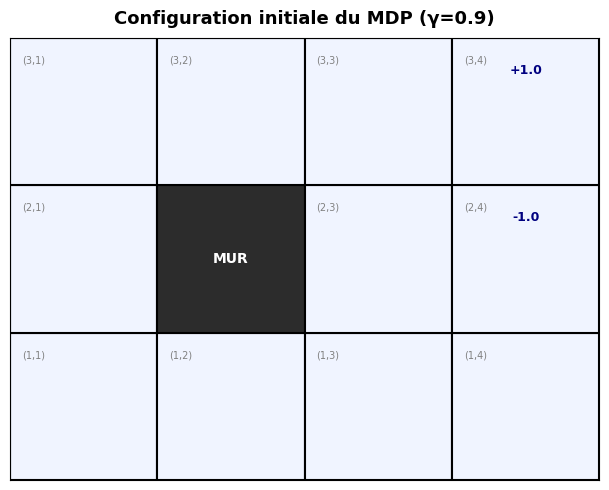

Grille initiale affichée.


In [8]:
# ── Visualisation de la grille ───────────────────────────────────────────────

def plot_grid(V=None, policy=None, title="Grille MDP", ax=None, show_values=True):
    """Affiche la grille avec les valeurs et/ou la politique."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    
    ax.set_xlim(0, N_COLS)
    ax.set_ylim(0, N_ROWS)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    
    # Colormap centrée sur 0
    if V is not None:
        v_vals = [V[S2I[s]] for s in STATES]
        vmin, vmax = min(v_vals), max(v_vals)
        # Ensure vmin < 0 < vmax for TwoSlopeNorm to work properly
        if vmin >= 0:
            vmin = -0.01
        if vmax <= 0:
            vmax = 0.01
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    for x in range(1, N_ROWS+1):
        for y in range(1, N_COLS+1):
            # Coordonnées matplotlib (y en abscisse, x en ordonnée)
            col = y - 1
            row = x - 1
            
            if (x, y) == OBSTACLE:
                rect = patches.Rectangle((col, row), 1, 1,
                                         linewidth=1.5, edgecolor='black',
                                         facecolor='#2c2c2c')
                ax.add_patch(rect)
                ax.text(col+0.5, row+0.5, 'MUR', ha='center', va='center',
                        color='white', fontsize=10, fontweight='bold')
            else:
                s = (x, y)
                i = S2I[s]
                
                # Couleur selon la valeur
                if V is not None:
                    v = V[i]
                    c = plt.cm.RdYlGn(norm(v))
                    facecolor = c
                else:
                    facecolor = '#f0f4ff'
                
                rect = patches.Rectangle((col, row), 1, 1,
                                         linewidth=1.5, edgecolor='black',
                                         facecolor=facecolor)
                ax.add_patch(rect)
                
                # Récompense spéciale
                if s in REWARDS:
                    r_txt = f"+{REWARDS[s]}" if REWARDS[s] > 0 else str(REWARDS[s])
                    ax.text(col+0.5, row+0.78, r_txt, ha='center', va='center',
                            fontsize=9, color='navy', fontweight='bold')
                
                # Valeur V
                if V is not None and show_values:
                    ax.text(col+0.5, row+0.42, f"{V[i]:.3f}", ha='center',
                            va='center', fontsize=9, color='black')
                
                # Action (flèche)
                if policy is not None:
                    a = ACTIONS[policy[i]]
                    ax.text(col+0.5, row+0.22, ARROWS[a], ha='center',
                            va='center', fontsize=14, color='#1a1a8c')
                
                # Coordonnée état
                ax.text(col+0.08, row+0.88, f"({x},{y})", ha='left',
                        va='top', fontsize=7, color='gray')
    
    # Grille
    for x in range(N_COLS+1):
        ax.axvline(x, color='black', linewidth=0.5)
    for y in range(N_ROWS+1):
        ax.axhline(y, color='black', linewidth=0.5)
    
    ax.set_xticks([])
    ax.set_yticks([])
    return ax

# Affichage de la grille initiale
fig, ax = plt.subplots(figsize=(7, 5))
plot_grid(title="Configuration initiale du MDP (γ=0.9)", ax=ax)
plt.tight_layout()
plt.savefig('grille_initiale.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grille initiale affichée.")

## Question 1 — Value Iteration (Itération sur la valeur)

L'algorithme applique répétitivement l'opérateur de Bellman jusqu'à convergence :

$$V_{k+1}(s) = R(s) + \gamma \cdot \max_{a \in A} \sum_{s' \in S} P(s' \mid s, a) \cdot V_k(s')$$

L'arrêt est déclenché quand $\delta = \max_s |V_{k+1}(s) - V_k(s)| < \varepsilon$.

Value Iteration convergée en 131 itérations (γ=0.9, ε=1e-06)

Fonction de valeur V* et politique optimale :
    État       V*(s)  Action
------------------------------
  (1, 1)     4.59593    N
  (1, 2)     5.14979    E
  (1, 3)     5.86504    N
  (1, 4)     5.82822    N
  (2, 1)     5.16503    N
  (2, 3)     6.77364    N
  (2, 4)     6.63309    N
  (3, 1)     5.88239    E
  (3, 2)     6.78907    E
  (3, 3)     7.73199    E
  (3, 4)     8.92568    N


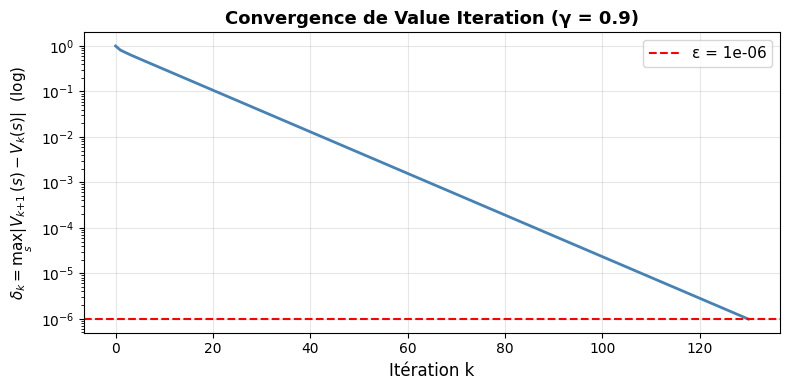

In [9]:
def value_iteration(P, R, gamma=0.9, epsilon=1e-6):
    """
    Value Iteration : applique l'opérateur de Bellman jusqu'à convergence.
    Q[i,a] = sum_{j} P[j,i,a] * V[j]  →  shape (N_STATES, N_ACTIONS)
    V_new[i] = R[i] + gamma * max_a Q[i,a]
    """
    V = np.zeros(N_STATES)
    deltas = []
    
    for iteration in range(10000):
        # Calcul vectorisé : P[j,i,a] * V[j] sommé sur j
        Q = (P * V[:, None, None]).sum(axis=0)   # shape (N_STATES, N_ACTIONS)
        V_new = R + gamma * Q.max(axis=1)
        
        delta = np.max(np.abs(V_new - V))
        deltas.append(delta)
        V = V_new.copy()
        
        if delta < epsilon:
            break
    
    # Politique optimale
    Q_final = (P * V[:, None, None]).sum(axis=0)
    policy  = Q_final.argmax(axis=1)
    
    return V, policy, iteration + 1, deltas

# ── Exécution ────────────────────────────────────────────────────────────────
V_vi, pol_vi, n_iter_vi, deltas_vi = value_iteration(P, R, gamma=GAMMA, epsilon=EPSILON)

print(f"Value Iteration convergée en {n_iter_vi} itérations (γ={GAMMA}, ε={EPSILON})")
print("\nFonction de valeur V* et politique optimale :")
print(f"{'État':>8}  {'V*(s)':>10}  {'Action':>6}")
print("-" * 30)
for s in sorted(STATES):
    i = S2I[s]
    print(f"{str(s):>8}  {V_vi[i]:>10.5f}    {ACTIONS[pol_vi[i]]}")

# ── Courbe de convergence ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(deltas_vi, color='steelblue', linewidth=2)
ax.axhline(EPSILON, color='red', linestyle='--', linewidth=1.5, label=f'ε = {EPSILON}')
ax.set_xlabel("Itération k", fontsize=12)
ax.set_ylabel(r"$\delta_k = \max_s |V_{k+1}(s) - V_k(s)|$  (log)", fontsize=11)
ax.set_title("Convergence de Value Iteration (γ = 0.9)", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('convergence_VI.png', dpi=120, bbox_inches='tight')
plt.show()

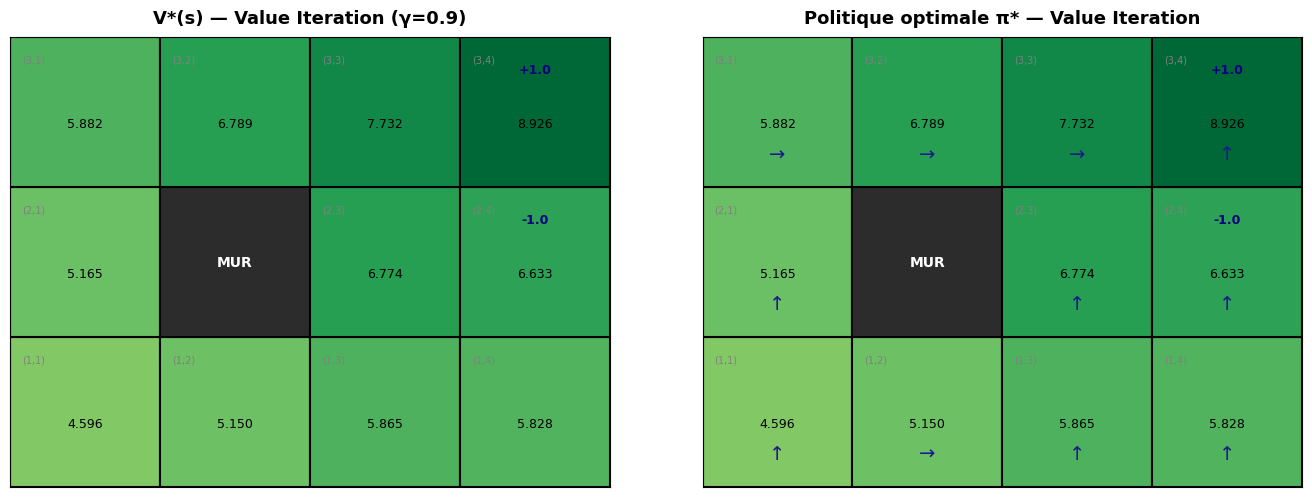


=== Influence du facteur d'escompte γ ===
  γ=0.10 →   7 itérations  |  V*(1,1) = +0.0000
  γ=0.50 →  21 itérations  |  V*(1,1) = +0.0324
  γ=0.90 → 131 itérations  |  V*(1,1) = +4.5959
  γ=0.99 → 1363 itérations  |  V*(1,1) = +82.3592


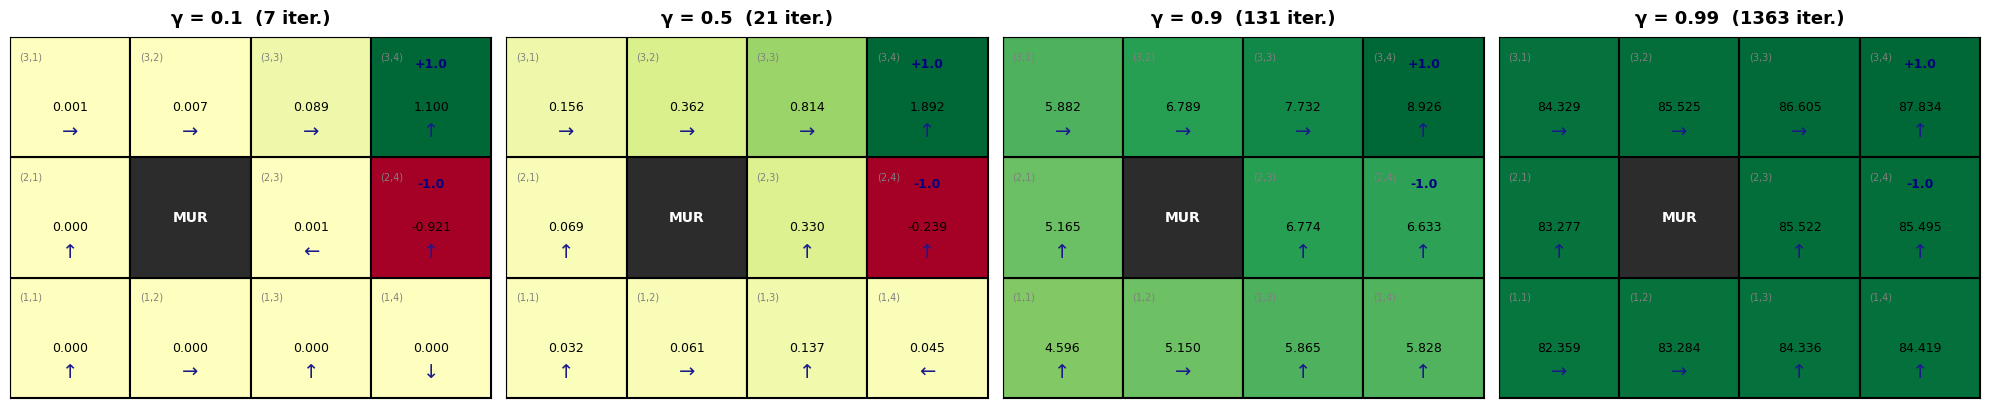

In [10]:
# ── Affichage V* et politique optimale ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_grid(V=V_vi, title="V*(s) — Value Iteration (γ=0.9)", ax=axes[0], show_values=True)
plot_grid(V=V_vi, policy=pol_vi, title="Politique optimale π* — Value Iteration", ax=axes[1])
plt.tight_layout()
plt.savefig('VI_resultats.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Effet de γ sur la politique ──────────────────────────────────────────────
print("\n=== Influence du facteur d'escompte γ ===")
gammas = [0.1, 0.5, 0.9, 0.99]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, g in zip(axes, gammas):
    V_g, pol_g, nit_g, _ = value_iteration(P, R, gamma=g, epsilon=EPSILON)
    plot_grid(V=V_g, policy=pol_g, title=f"γ = {g}  ({nit_g} iter.)", ax=ax)
    print(f"  γ={g:4.2f} → {nit_g:3d} itérations  |  V*(1,1) = {V_g[S2I[(1,1)]]:+.4f}")

plt.tight_layout()
plt.savefig('VI_gamma.png', dpi=120, bbox_inches='tight')
plt.show()

## Question 2: Policy Iteration (Itération sur la politique)

Chaque itération comporte deux étapes :

1. **Évaluation exacte** de la politique courante : résoudre le système linéaire  
   $$(I - \gamma P^\pi) \mathbf{v}^\pi = \mathbf{r}$$

2. **Amélioration** : mettre à jour la politique par maximisation glouton  
   $$\pi_{\text{new}}(s) = \arg\max_{a} \sum_{s'} P(s' \mid s, a)\, v^\pi(s')$$

L'algorithme s'arrête quand la politique ne change plus.

In [11]:
def policy_iteration(P, R, gamma=0.9):
    """
    Policy Iteration : alternance entre évaluation exacte et amélioration glouton.
    Évaluation : résout (I - γ P^π) v = r  par np.linalg.solve
    Amélioration : π_new(s) = argmax_a Σ_s' P(s'|s,a) v(s')
    """
    policy = np.zeros(N_STATES, dtype=int)   # initialisation : toujours Nord
    
    for iteration in range(1000):
        # Étape A — Évaluation exacte
        # P_pi[j, i] = P(s'=j | s=i, a=π(i))
        P_pi = np.array([[P[j, i, policy[i]] for i in range(N_STATES)]
                          for j in range(N_STATES)])
        # Système : (I - γ P_pi^T) v = R  (convention P_pi colonnes = état courant)
        A_mat = np.eye(N_STATES) - gamma * P_pi.T
        V = np.linalg.solve(A_mat, R)
        
        # Étape B — Amélioration glouton
        Q = (P * V[:, None, None]).sum(axis=0)
        policy_new = Q.argmax(axis=1)
        
        # Étape C — Convergence
        if np.array_equal(policy_new, policy):
            break
        policy = policy_new
    
    return V, policy, iteration + 1

# ── Exécution et chronométrage ────────────────────────────────────────────────
import time

t0 = time.time()
V_vi2, pol_vi2, n_vi, _ = value_iteration(P, R, GAMMA, EPSILON)
t_vi = time.time() - t0

t0 = time.time()
V_pi, pol_pi, n_pi = policy_iteration(P, R, GAMMA)
t_pi = time.time() - t0

# ── Tableau comparatif ────────────────────────────────────────────────────────
print("=" * 52)
print(f"{'Algorithme':<22} {'Itérations':>10} {'Temps':>12}")
print("-" * 52)
print(f"{'Value Iteration':<22} {n_vi:>10} {t_vi*1000:>10.2f}ms")
print(f"{'Policy Iteration':<22} {n_pi:>10} {t_pi*1000:>10.2f}ms")
print("=" * 52)
print(f"\nPolitiques identiques  : {np.array_equal(pol_vi2, pol_pi)}")
print(f"Valeurs concordantes   : {np.allclose(V_vi2, V_pi, atol=1e-4)}")

Algorithme             Itérations        Temps
----------------------------------------------------
Value Iteration               131       1.66ms
Policy Iteration                3       0.31ms

Politiques identiques  : True
Valeurs concordantes   : True


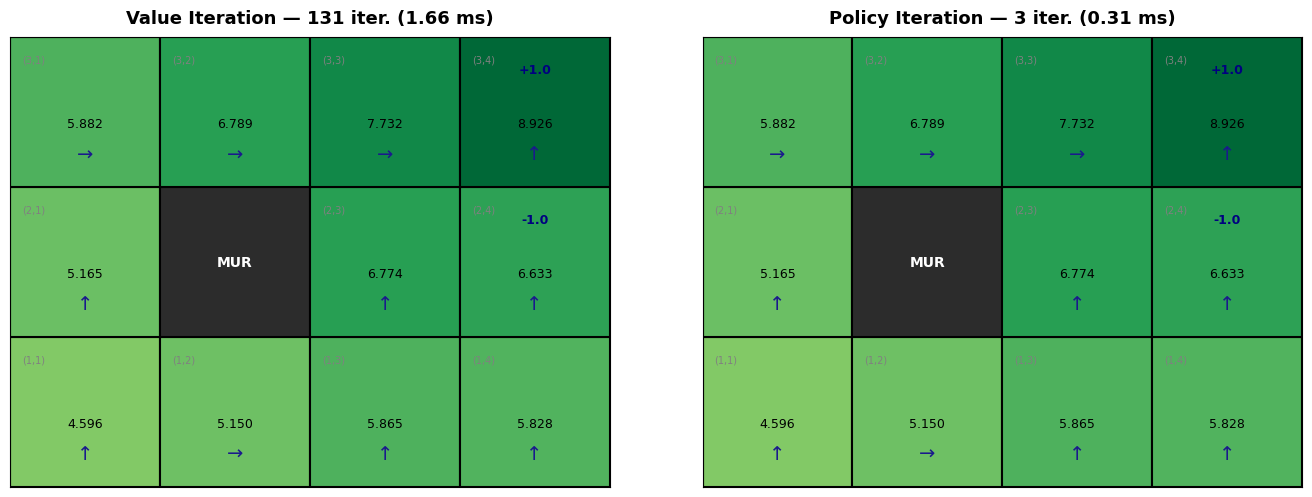


    État       V*(VI)       V*(PI)   Act-VI   Act-PI
-------------------------------------------------------
  (1, 1)       4.59593       4.59594       N       N
  (1, 2)       5.14979       5.14980       E       E
  (1, 3)       5.86504       5.86505       N       N
  (1, 4)       5.82822       5.82823       N       N
  (2, 1)       5.16503       5.16504       N       N
  (2, 3)       6.77364       6.77365       N       N
  (2, 4)       6.63309       6.63310       N       N
  (3, 1)       5.88239       5.88240       E       E
  (3, 2)       6.78907       6.78907       E       E
  (3, 3)       7.73199       7.73200       E       E
  (3, 4)       8.92568       8.92569       N       N


In [12]:
# ── Comparaison visuelle VI vs PI ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_grid(V=V_vi2, policy=pol_vi2,
          title=f"Value Iteration — {n_vi} iter. ({t_vi*1000:.2f} ms)", ax=axes[0])
plot_grid(V=V_pi,  policy=pol_pi,
          title=f"Policy Iteration — {n_pi} iter. ({t_pi*1000:.2f} ms)", ax=axes[1])
plt.tight_layout()
plt.savefig('comparaison_VI_PI.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Tableau des valeurs finales ───────────────────────────────────────────────
print("\n{:>8} {:>12} {:>12} {:>8} {:>8}".format(
      "État", "V*(VI)", "V*(PI)", "Act-VI", "Act-PI"))
print("-" * 55)
for s in sorted(STATES):
    i = S2I[s]
    print(f"  {str(s):>6}  {V_vi2[i]:>12.5f}  {V_pi[i]:>12.5f}  "
          f"  {ACTIONS[pol_vi2[i]]:>4}    {ACTIONS[pol_pi[i]]:>4}")